# X-ray Ptychography Reconstruction with Tike

This notebook demonstrates X-ray ptychographic reconstruction of a Siemens star pattern
from far-field diffraction intensity measurements. Ptychography is a scanning coherent
imaging technique that recovers both the complex-valued object transmission function and
the illumination probe by solving an inverse problem from overlapping diffraction patterns.

## The Inverse Problem

In ptychography, a focused X-ray probe $P(\mathbf{r})$ is scanned across an object
$O(\mathbf{r})$ at positions $\{\mathbf{r}_j\}$. At each position, the exit wave is
$\psi_j(\mathbf{r}) = O(\mathbf{r}) \cdot P(\mathbf{r} - \mathbf{r}_j)$, and the
measured intensity is $I_j(\mathbf{q}) = |\mathcal{F}[\psi_j](\mathbf{q})|^2$.

Given only the intensities $\{I_j\}$ (phase information is lost), we must recover both
$O$ and $P$. This is solved iteratively using tike's least-squares gradient descent
(lstsq_grad) algorithm with mini-batching.

## Outline

1. Load and inspect the raw data
2. Preprocess: shift scan positions, initialize object array
3. Examine the probe guess
4. Review precomputed reconstruction results
5. Visualize: object phase, probe, cost curve, comparison with baseline

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Set up paths
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

DATA_DIR = os.path.join(TASK_DIR, 'data')
REF_DIR = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

print(f'Task directory: {TASK_DIR}')

Task directory: /projects/bgkc/schen47/sota_imaging_101/imaging-101/tasks/xray_ptychography_tike


## 1. Load Raw Data

The dataset contains 516 diffraction patterns collected from a Siemens star sample
at the Velociprobe instrument (APS). Each pattern is 128x128 pixels of measured
far-field intensity. We also have scan positions and an initial probe guess.

In [2]:
from src.preprocessing import load_raw_data, load_metadata

raw = load_raw_data(DATA_DIR)
meta = load_metadata(DATA_DIR)

data = raw['diffraction_patterns']
scan = raw['scan_positions']
probe_guess = raw['probe_guess']

print(f'Diffraction patterns: {data.shape}, dtype={data.dtype}')
print(f'Scan positions:       {scan.shape}, dtype={scan.dtype}')
print(f'Probe guess:          {probe_guess.shape}, dtype={probe_guess.dtype}')
print(f'Number of positions:  {meta["n_positions"]}')
print(f'Data range:           [{data.min():.1f}, {data.max():.1f}]')

Diffraction patterns: (516, 128, 128), dtype=float32
Scan positions:       (516, 2), dtype=float32
Probe guess:          (1, 1, 1, 128, 128), dtype=complex64
Number of positions:  516
Data range:           [0.0, 963.0]


### Scan Positions

The scan positions show where the probe was placed on the sample.
Adjacent positions overlap, which provides the redundancy needed for phase retrieval.

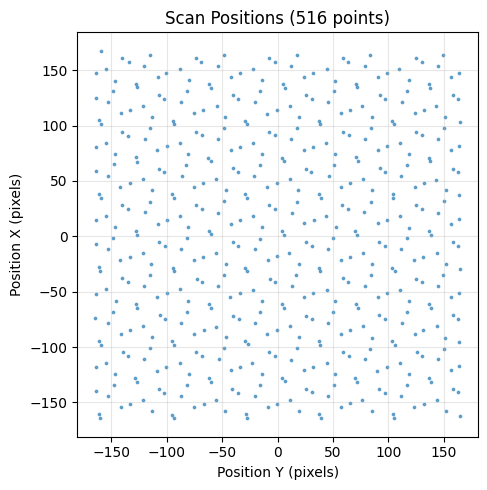

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(scan[:, 1], scan[:, 0], s=3, alpha=0.6)
ax.set_xlabel('Position Y (pixels)')
ax.set_ylabel('Position X (pixels)')
ax.set_title(f'Scan Positions ({scan.shape[0]} points)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Example Diffraction Pattern

Each diffraction pattern captures the squared magnitude of the Fourier transform
of the exit wave (probe times object). The central bright spot and surrounding
rings encode the spatial frequency content of the illuminated region.

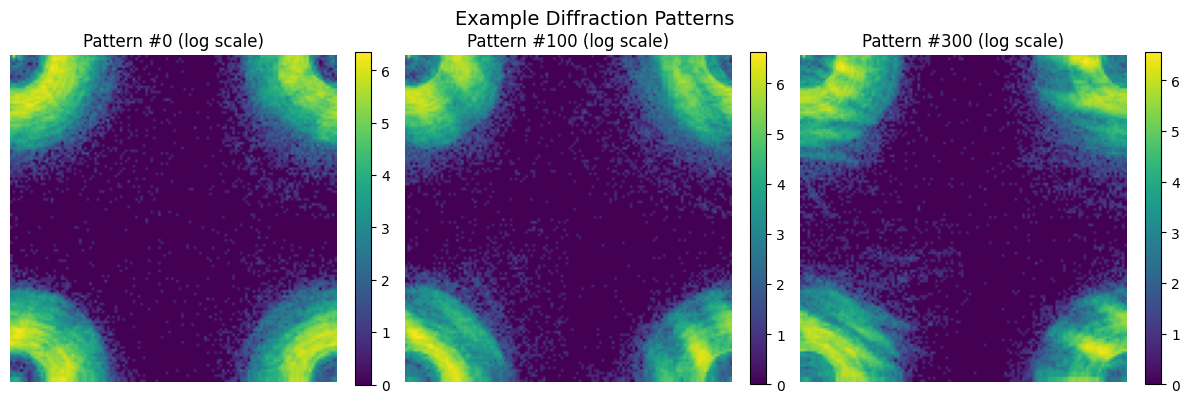

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, idx in enumerate([0, 100, 300]):
    im = axes[i].imshow(np.log1p(data[idx]), cmap='viridis')
    axes[i].set_title(f'Pattern #{idx} (log scale)')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Example Diffraction Patterns', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Preprocessing

Before reconstruction, we:
1. Shift scan positions so the minimum coordinate equals a buffer offset (20 pixels)
2. Initialize the object array (psi) sized to contain all scan positions plus the probe footprint

The object is initialized as a uniform complex constant (0.5+0j).

In [5]:
from src.preprocessing import shift_scan_positions, initialize_psi

scan_shifted = shift_scan_positions(scan, offset=20.0)
psi_init = initialize_psi(scan_shifted, probe_shape=probe_guess.shape)

print(f'Scan range before shift: [{scan.min():.1f}, {scan.max():.1f}]')
print(f'Scan range after shift:  [{scan_shifted.min():.1f}, {scan_shifted.max():.1f}]')
print(f'Object array (psi):      {psi_init.shape}, dtype={psi_init.dtype}')
print(f'Object fill value:       {psi_init[0, 0, 0]}')

Scan range before shift: [-164.4, 167.6]
Scan range after shift:  [20.0, 351.9]
Object array (psi):      (1, 482, 479), dtype=complex64
Object fill value:       (0.5+0j)


## 3. Probe Guess

The initial probe guess is a complex-valued 2D array representing the focused
X-ray illumination. Its phase encodes the wavefront shape (e.g., aberrations)
and its amplitude encodes the beam profile.

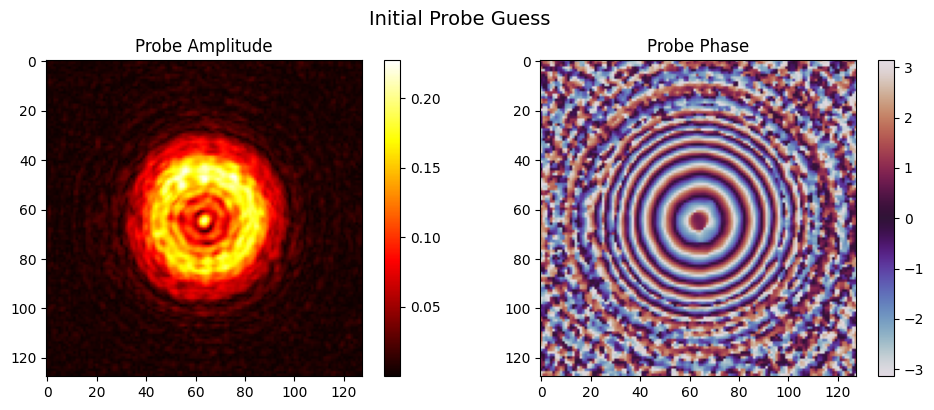

In [6]:
# Probe has shape (1, 1, n_modes, W, H) -- extract single mode
probe_2d = probe_guess[0, 0, 0]  # (128, 128)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(np.abs(probe_2d), cmap='hot')
axes[0].set_title('Probe Amplitude')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.angle(probe_2d), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Probe Phase')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('Initial Probe Guess', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Reconstruction Results (Precomputed)

The full reconstruction was run with 64 epochs, 7 mini-batches per epoch,
using tike's lstsq_grad algorithm. We load the precomputed results here
so this notebook runs in seconds.

To run the full reconstruction from scratch (requires GPU):
```python
# from src.preprocessing import add_probe_modes
# from src.solvers import reconstruct
#
# probe = add_probe_modes(probe_guess, n_modes=1)
# result = reconstruct(
#     data=data,
#     scan=scan_shifted,
#     probe=probe,
#     psi=psi_init,
#     num_iter=64,
#     num_batch=7,
# )
# recon_object = result.psi
# recon_probe = result.probe
# costs = np.array(result.algorithm_options.costs)
```

In [7]:
# Load precomputed results
recon_object = np.load(os.path.join(REF_DIR, 'reconstructed_object.npy'))
recon_probe = np.load(os.path.join(REF_DIR, 'reconstructed_probe.npy'))
costs = np.load(os.path.join(REF_DIR, 'costs.npy'))

print(f'Reconstructed object: {recon_object.shape}, dtype={recon_object.dtype}')
print(f'Reconstructed probe:  {recon_probe.shape}, dtype={recon_probe.dtype}')
print(f'Cost history:         {costs.shape}')

Reconstructed object: (482, 479), dtype=complex64
Reconstructed probe:  (1, 1, 1, 128, 128), dtype=complex64
Cost history:         (64, 1)


### Cost Curve

The cost function measures the mismatch between measured and simulated diffraction
patterns. Monotonic decrease indicates the algorithm is converging.

Initial cost: 2.1619
Final cost:   0.3276
Reduction:    6.6x


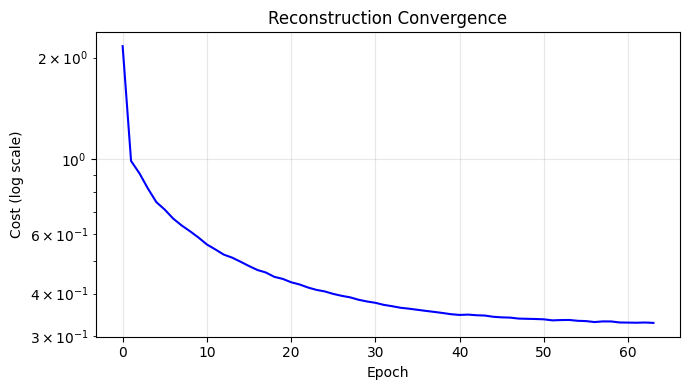

In [8]:
# costs may be 2D (iterations x batches) -- average across batches
if costs.ndim == 2:
    cost_per_iter = costs.mean(axis=1)
else:
    cost_per_iter = costs

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(cost_per_iter, 'b-', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (log scale)')
ax.set_title('Reconstruction Convergence')
ax.grid(True, alpha=0.3)
print(f'Initial cost: {cost_per_iter[0]:.4f}')
print(f'Final cost:   {cost_per_iter[-1]:.4f}')
print(f'Reduction:    {cost_per_iter[0] / cost_per_iter[-1]:.1f}x')
plt.tight_layout()
plt.show()

### Reconstructed Object Phase

The phase of the complex object transmission function reveals the sample's
structure. For the Siemens star pattern, we expect radial spokes with
increasing spatial frequency toward the center.

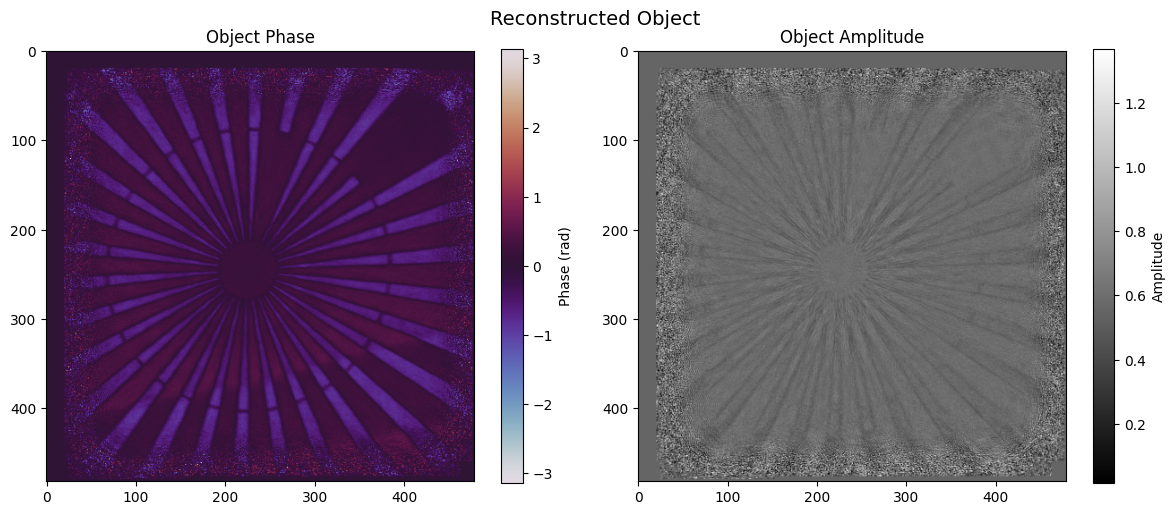

In [9]:
# recon_object may be 2D or 3D (with depth slice dim)
obj_2d = recon_object[0] if recon_object.ndim == 3 else recon_object

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(np.angle(obj_2d), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0].set_title('Object Phase')
plt.colorbar(im0, ax=axes[0], label='Phase (rad)')

im1 = axes[1].imshow(np.abs(obj_2d), cmap='gray')
axes[1].set_title('Object Amplitude')
plt.colorbar(im1, ax=axes[1], label='Amplitude')

plt.suptitle('Reconstructed Object', fontsize=14)
plt.tight_layout()
plt.show()

### Reconstructed Probe

The probe is also refined during reconstruction. Comparing the initial
guess with the reconstructed probe shows how the algorithm corrects
the illumination model.

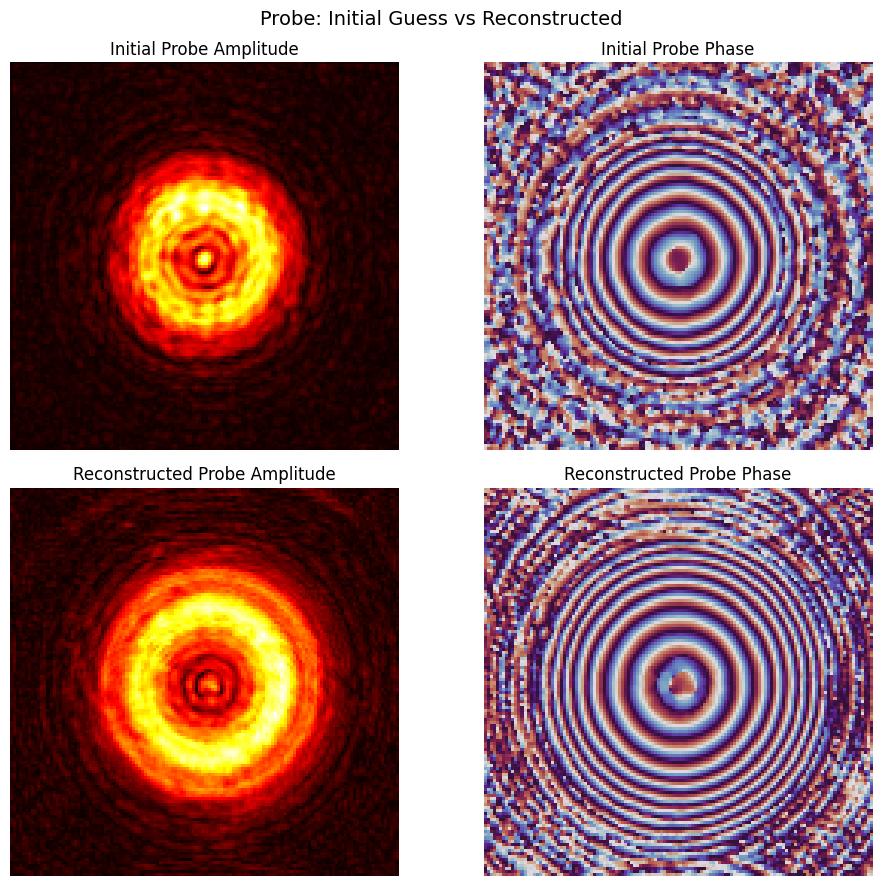

In [10]:
recon_probe_2d = recon_probe[0, 0, 0]  # (W, H)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

# Initial probe
axes[0, 0].imshow(np.abs(probe_2d), cmap='hot')
axes[0, 0].set_title('Initial Probe Amplitude')
axes[0, 1].imshow(np.angle(probe_2d), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title('Initial Probe Phase')

# Reconstructed probe
axes[1, 0].imshow(np.abs(recon_probe_2d), cmap='hot')
axes[1, 0].set_title('Reconstructed Probe Amplitude')
axes[1, 1].imshow(np.angle(recon_probe_2d), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title('Reconstructed Probe Phase')

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle('Probe: Initial Guess vs Reconstructed', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Comparison with Baseline Reference

We compare the reconstructed object phase against a baseline reference
using normalized cross-correlation (NCC) and normalized root-mean-square
error (NRMSE).

NCC measures the cosine similarity between flattened vectors:

$$\text{NCC} = \frac{\hat{x} \cdot x_{\text{ref}}}{\|\hat{x}\| \, \|x_{\text{ref}}\|}$$

NRMSE normalizes the RMS error by the dynamic range of the reference:

$$\text{NRMSE} = \frac{\sqrt{\frac{1}{N}\sum_i (\hat{x}_i - x_{\text{ref},i})^2}}{\max(x_{\text{ref}}) - \min(x_{\text{ref}})}$$

In [11]:
from src.visualization import compute_metrics

# Load baseline reference
baseline = np.load(os.path.join(DATA_DIR, 'baseline_reference.npz'))
ref_phase = baseline['object_phase']    # (1, 482, 479)
ref_amp = baseline['object_amplitude']  # (1, 482, 479)

# Compute estimated phase
est_phase = np.angle(recon_object)
if est_phase.ndim == 2:
    est_phase = est_phase[np.newaxis]  # add depth dim to match

# Crop to matching shape
min_h = min(est_phase.shape[-2], ref_phase.shape[-2])
min_w = min(est_phase.shape[-1], ref_phase.shape[-1])
est_crop = est_phase[:, :min_h, :min_w]
ref_crop = ref_phase[:, :min_h, :min_w]

metrics = compute_metrics(est_crop, ref_crop)
print(f'NCC:   {metrics["ncc"]:.4f}')
print(f'NRMSE: {metrics["nrmse"]:.4f}')

NCC:   1.0000
NRMSE: 0.0000


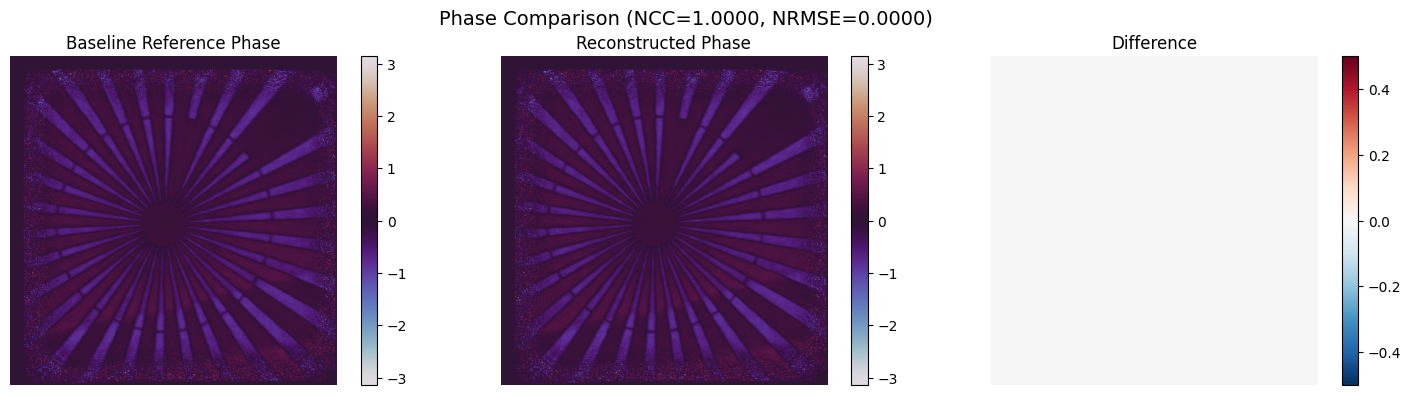

In [12]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(ref_crop[0], cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0].set_title('Baseline Reference Phase')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(est_crop[0], cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Reconstructed Phase')
plt.colorbar(im1, ax=axes[1])

diff = est_crop[0] - ref_crop[0]
im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[2].set_title('Difference')
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.axis('off')

plt.suptitle(f'Phase Comparison (NCC={metrics["ncc"]:.4f}, NRMSE={metrics["nrmse"]:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the complete X-ray ptychography reconstruction pipeline:

1. **Data**: 516 diffraction patterns (128x128) from a Siemens star sample
2. **Preprocessing**: Scan position shifting, object array initialization
3. **Reconstruction**: 64 epochs of lstsq_grad with 7 mini-batches (via tike)
4. **Results**: Clear Siemens star structure recovered in the object phase
5. **Evaluation**: High NCC with baseline reference confirms reconstruction quality

The reconstruction jointly recovers the object transmission function and the
illumination probe, making ptychography a powerful technique for high-resolution
X-ray imaging without requiring a lens.